In [ ]:
# google drive mount

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extract dataset

!unzip -q "/content/drive/MyDrive/archive (10).zip" -d /content/dataset

In [ ]:
# Check dataset Structure

import os

for root, dirs, files in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        for file in files[:5]:
            print(f"{indent}  {file}")

dataset/
  New Plant Diseases Dataset(Augmented)/
    New Plant Diseases Dataset(Augmented)/
      valid/
        Raspberry___healthy/
        Blueberry___healthy/
        Soybean___healthy/
        Pepper,_bell___healthy/
        Strawberry___Leaf_scorch/
        Corn_(maize)___Common_rust_/
        Peach___Bacterial_spot/
        Potato___Early_blight/
        Tomato___Septoria_leaf_spot/
        Tomato___healthy/
        Potato___Late_blight/
        Tomato___Tomato_mosaic_virus/
        Peach___healthy/
        Corn_(maize)___healthy/
        Corn_(maize)___Northern_Leaf_Blight/
        Strawberry___healthy/
        Tomato___Early_blight/
        Grape___Esca_(Black_Measles)/
        Grape___Leaf_blight_(Isariopsis_Leaf_Spot)/
        Grape___healthy/
        Squash___Powdery_mildew/
        Grape___Black_rot/
        Tomato___Late_blight/
        Apple___Cedar_apple_rust/
        Tomato___Spider_mites Two-spotted_spider_mite/
        Tomato___Tomato_Yellow_Leaf_Curl_Virus/
       

In [ ]:
pip install tf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
# Import required libraries

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

In [ ]:
# Verify dataset structure

for root, dirs, files in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    if level > 2:
        continue
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

dataset/
  New Plant Diseases Dataset(Augmented)/
    New Plant Diseases Dataset(Augmented)/
  new plant diseases dataset(augmented)/
    New Plant Diseases Dataset(Augmented)/
  test/
    test/


In [ ]:
# Check dataset folders

inner_path = "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
print(os.listdir(inner_path))

['valid', 'train']


In [ ]:
# Set train and validation paths

base_dir = "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "valid")

print("Train classes:", len(os.listdir(train_dir)))
print("Val classes:", len(os.listdir(val_dir)))

Train classes: 38
Val classes: 38


In [ ]:
# Load training and validation images,resize them and organize batches

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Classes: 38


In [ ]:
# Improve data pipeline performance

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
# Apply random transformation to improve model generalization

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

In [ ]:
# Buils CNN model with convolution,pooling,and classification layers

model = models.Sequential([
    layers.InputLayer(input_shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465,894 (1.78 MB)

 Trainable params: 464,934 (1.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Calculate balance class weights for training

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

In [ ]:
# Set callbacks to prevent overfitting and save the best model

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "crop_disease_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

# Train the CNN model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 309s 136ms/step - accuracy: 0.6765 - loss: 1.0849 - val_accuracy: 0.7743 - val_loss: 0.7025
Epoch 2/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 298s 136ms/step - accuracy: 0.8839 - loss: 0.3708 - val_accuracy: 0.8209 - val_loss: 0.5970
Epoch 3/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 297s 135ms/step - accuracy: 0.9303 - loss: 0.2202 - val_accuracy: 0.7437 - val_loss: 0.9338
Epoch 4/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 296s 135ms/step - accuracy: 0.9499 - loss: 0.1581 - val_accuracy: 0.8042 - val_loss: 0.7198
Epoch 5/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 300s 136ms/step - accuracy: 0.9575 - loss: 0.1324 - val_accuracy: 0.8158 - val_loss: 0.6937
Epoch 6/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 297s 135ms/step - accuracy: 0.9640 - loss: 0.1119 - val_accuracy: 0.8567 - val_loss: 0.4660
Epoch 7/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 297s 135ms/step - accuracy: 0.9695 - loss: 0.0955 - val_accuracy: 0.9184 - val_loss: 0.2844
Epoch 8/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 297s 135ms/step - ac

In [ ]:
# Save the trained model to google drive

import shutil
shutil.copy("/content/crop_disease_model.keras", "/content/drive/MyDrive/crop_disease_model_cnn.keras")

'/content/drive/MyDrive/crop_disease_model_cnn.keras'

In [ ]:
# Load the save model

model = tf.keras.models.load_model('/content/drive/MyDrive/crop_disease_model_cnn.keras')
print("Model load successfully")

Model successfully load ho gaya hai!


550/550 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      1.00      1.00       504
                                 Apple___Black_rot       1.00      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      0.99      1.00       440
                                   Apple___healthy       0.98      1.00      0.99       502
                               Blueberry___healthy       0.99      0.99      0.99       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.99      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       1.00      0.90      0.95       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northe

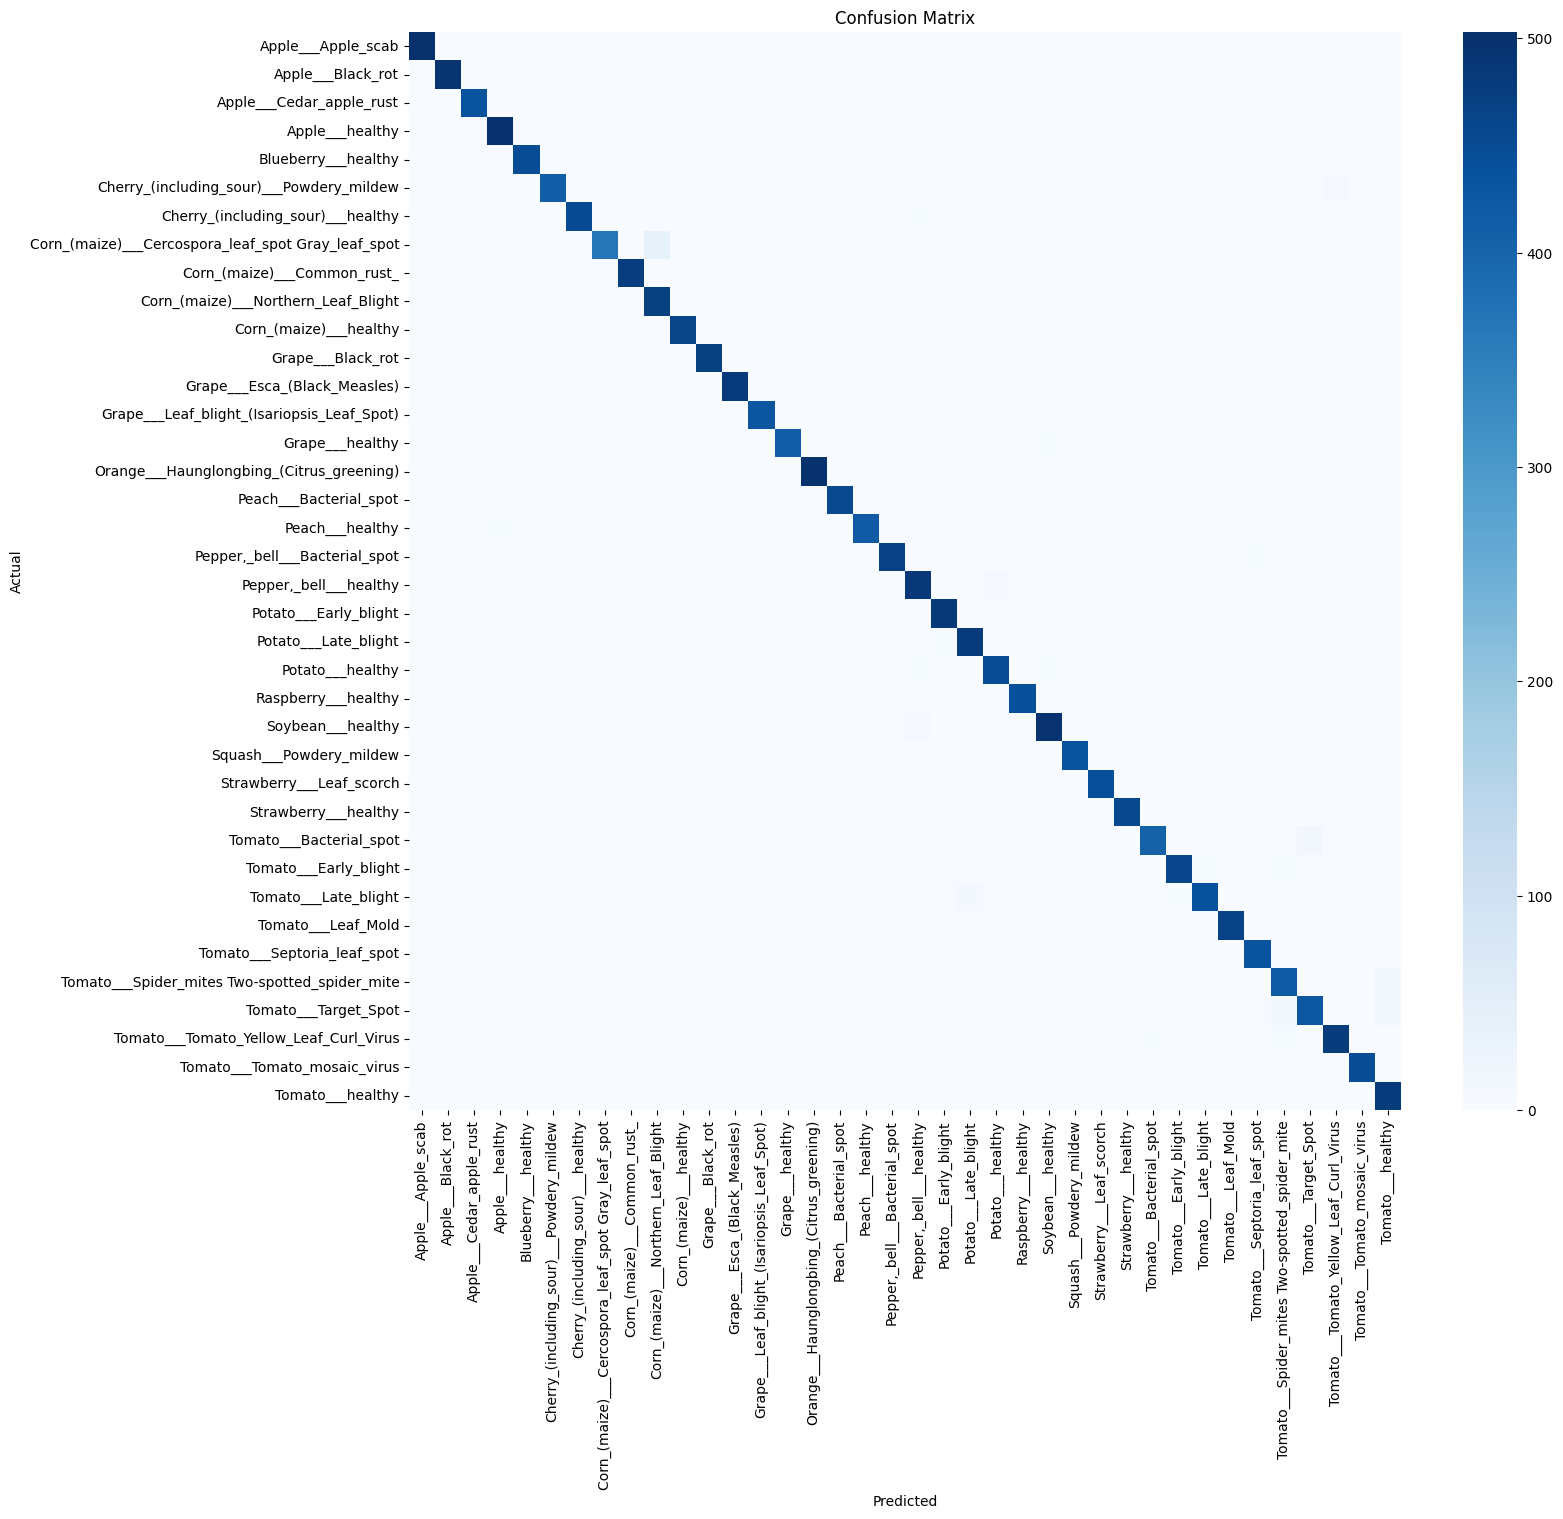

In [ ]:
# Model Evaluation and generate the confusion matrix

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate pridictions

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds), axis=1)

# Generate classification report

print(classification_report(y_true, y_pred, target_names=class_names))

# plot confusion matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16,14))
sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

NameError: name 'history' is not defined

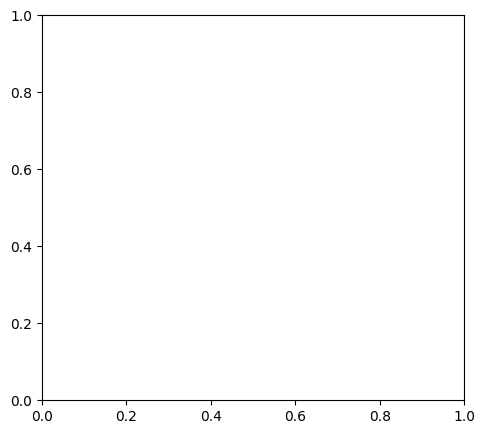

In [ ]:
# Plot training and validation performance

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# define function to predict disease from an image

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_disease(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    predicted_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence:.2f}%)")
    plt.show()

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


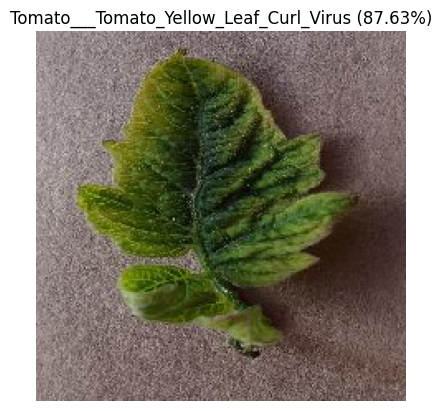

('Tomato___Tomato_Yellow_Leaf_Curl_Virus', np.float32(87.63482))

In [ ]:
# Test the model

predict_disease("/content/TomatoYellowCurlVirus1.JPG")